# K-means
### Author: Krzysztof Chmielewski

K-means is an algorithm that groups dataset into $K$ clusters, where each point of given dataset belongs to its nearest cluster center. It calculates this by minimizing a loss: 
$$
J = \sum_{i=1}^n(\Vert x_i - \mu_{c_i} \Vert^2)
$$
where:
- $x_i$ is a data point
- $\mu_{c_i}$ is the mean of its assigned cluster

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import root_mean_squared_error

In [22]:
def compare_blobs_kmeans(X, y_true, model):
    y_pred = model.predict(X)

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # --- Left: real blob labels ---
    axs[0].scatter(X[:,0], X[:,1], c=y_true, cmap="viridis", s=50)
    axs[0].set_title("Real Blob Classes")
    axs[0].set_xlabel("x1")
    axs[0].set_ylabel("x2")

    # --- Right: k-means predicted clusters ---
    axs[1].scatter(X[:,0], X[:,1], c=y_pred, cmap="viridis", s=50)
    axs[1].scatter(model.centroids[:,0], model.centroids[:,1],
                   c="red", marker="X", s=200, edgecolors="black")
    axs[1].set_title("K-Means Predicted Clusters")
    axs[1].set_xlabel("x1")
    axs[1].set_ylabel("x2")

    plt.tight_layout()
    plt.show()


In [20]:
class Kmeans:
    def __init__(self, k: int = 2, max_iters: int = 100):
        self.k = k
        self.max_iters = max_iters

    def _compute_distances(self, X):
        return np.linalg.norm(
            X[:, np.newaxis, :] - self.centroids[np.newaxis, :, :],
            axis=2
        )
    
    def fit(self, X):
        n_samples, n_features = X.shape

        # initialize centroids with random data
        random_idx = np.random.choice(n_samples, self.k, replace=False)
        self.centroids = X[random_idx]

        for _ in range(self.max_iters):
            distances = self._compute_distances(X)
            self.labels = np.argmin(distances, axis=1)

            new_centroids = np.array([
                X[self.labels == i].mean(axis=0)
                if np.any(self.labels)
                else self.centroids[i]
                for i in range(self.k)
            ])

            if np.allclose(self.centroids, new_centroids):
                break

            self.centroids = new_centroids
    
    def predict(self, X):
        distances = self._compute_distances(X)
        return np.argmin(distances, axis=1)

RMSE:  1.6733200530681511


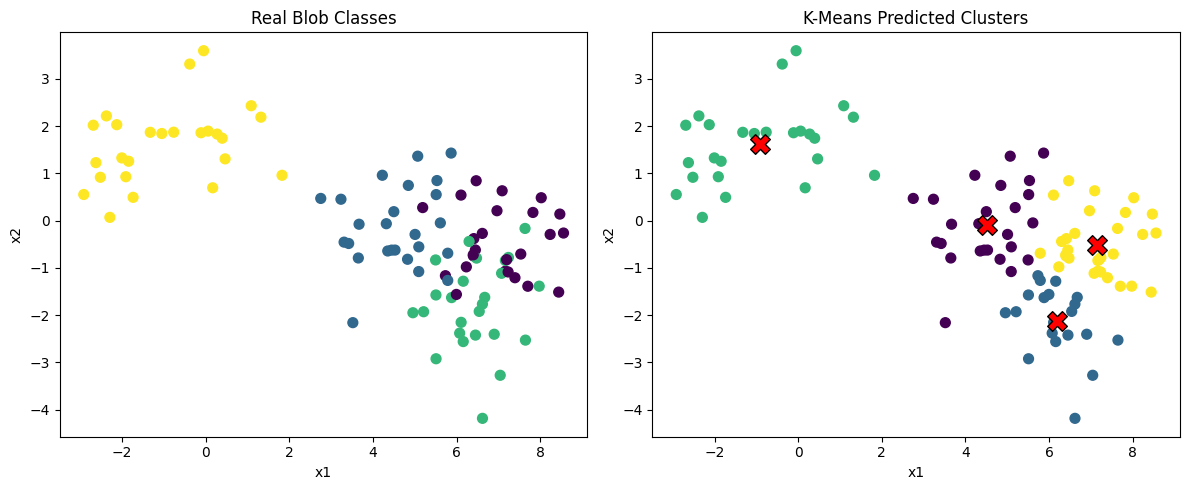

In [35]:
X, y = make_blobs(n_samples=100, centers=4)

km = Kmeans(k=4)
km.fit(X)

print('RMSE: ', root_mean_squared_error(y, km.predict(X)))

compare_blobs_kmeans(X, y, km)